<a href="https://colab.research.google.com/github/DavidOspino2005/Laboratorio/blob/main/Lab11_Visualizacion_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 11 — Introducción a la visualización de datos


**Autor:** David Ospino  
**Repositorio:** https://github.com/DavidOspino2005/Laboratorio

Contenido:
- **Ejercicio 1:** Detección de valores atípicos (outliers) en el dataset `Bike_Sales_Outlier_Lab.xlsx`
- **Ejercicio 2:** Cuatro escenarios de visualización con matplotlib y seaborn

## 0. Preparación del entorno

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


### Cargar el archivo de Excel



In [7]:
url = 'https://raw.githubusercontent.com/DavidOspino2005/Laboratorio/main/Bike_Sales_Outlier_Lab.xlsx'
data = pd.read_excel(url, sheet_name='Bike Sales')
data.columns = data.columns.str.strip()

print('Columnas del dataset:')
print(data.columns.tolist())
print(f'\nFilas: {data.shape[0]}  |  Columnas: {data.shape[1]}')
data.head()

Columnas del dataset:
['Sales_Order #', 'Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category', 'Sub_Category', 'Product_Description', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue']

Filas: 88  |  Columnas: 19


,Sales_Order #,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product_Description,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,261696,2021-12-01,1,December,2021,39,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",4,1252,2295,4172,5008,9180
1,261695,2021-12-01,1,December,2021,44,Adults (35-64),M,United Kingdom,England,Bikes,Mountain Bikes,"Mountain-200 Silver, 42",1,1266,2320,1054,1266,2320
2,261697,2021-12-02,2,December,2021,37,Adults (35-64),M,United States,California,Bikes,Mountain Bikes,"Mountain-400-W Silver, 46",2,420,769,698,840,1538
3,261698,2021-12-02,2,December,2021,31,Young Adults (25-34),F,Australia,New South Wales,Bikes,Mountain Bikes,"Mountain-400-W Silver, 42",1,420,769,349,420,769
4,261699,2021-12-03,3,December,2021,37,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",2,1252,2295,2086,2504,4590


---
# EJERCICIO DE PRÁCTICA 1 — Interpretación de visualizaciones con valores atípicos

## Paso 2 — Tabla dinámica (equivalente en Python)

En Excel se usa una tabla dinámica con los campos **Date** y **Order_Quantity**.  
En pandas el equivalente es un `groupby()` sobre la fecha sumando la cantidad de pedido.

In [8]:
# Tabla dinámica: suma de Order_Quantity por fecha
tabla_dinamica = data.groupby('Date')['Order_Quantity'].sum().reset_index()
tabla_dinamica.columns = ['Date', 'Sum_of_Order_Quantity']

print(f'Total general: {tabla_dinamica["Sum_of_Order_Quantity"].sum()}')
tabla_dinamica

Total general: 197


,Date,Sum_of_Order_Quantity
0,2021-12-01,5
1,2021-12-02,3
2,2021-12-03,4
3,2021-12-04,4
4,2021-12-05,10
5,2021-12-06,6
6,2021-12-07,6
7,2021-12-08,11
8,2021-12-09,3
9,2021-12-10,8


## Paso 3 — Ordenar los datos para encontrar valores atípicos

In [9]:
# Ordenar de mayor a menor (equivale a Ordenar y filtrar > Ordenar descendente)
ordenado = tabla_dinamica.sort_values('Sum_of_Order_Quantity', ascending=False).reset_index(drop=True)
ordenado.head(10)

,Date,Sum_of_Order_Quantity
0,2021-12-19,43
1,2021-12-18,19
2,2021-12-20,13
3,2021-12-12,12
4,2021-12-08,11
5,2021-12-05,10
6,2021-12-22,10
7,2021-12-10,8
8,2021-12-11,8
9,2021-12-07,6


In [10]:
# RESPUESTAS DEL PASO 3
fecha_max = ordenado.loc[0, 'Date']
cantidad_max = ordenado.loc[0, 'Sum_of_Order_Quantity']

print(f'¿En qué fecha de diciembre se registró la mayor cantidad de ventas?')
print(f'  -> {fecha_max.strftime("%d/%m/%Y")}\n')
print(f'¿Cuál fue la cantidad de ventas?')
print(f'  -> {cantidad_max} unidades')

¿En qué fecha de diciembre se registró la mayor cantidad de ventas?
  -> 19/12/2021

¿Cuál fue la cantidad de ventas?
  -> 43 unidades


In [11]:
# ¿Qué entrada (número de pedido) es la más responsable del valor atípico?
detalle_19dic = data[data['Date'] == fecha_max].sort_values('Order_Quantity', ascending=False)

print('Registros del 19 de diciembre ordenados por Order_Quantity:\n')
display(detalle_19dic[['Sales_Order #', 'Date', 'Product_Description', 'Order_Quantity', 'Revenue']])

pedido_culpable = detalle_19dic.iloc[0]
print(f'\n-> El pedido más responsable del valor atípico es: {pedido_culpable["Sales_Order #"]}')
print(f'   con una cantidad de {pedido_culpable["Order_Quantity"]} unidades.')

Registros del 19 de diciembre ordenados por Order_Quantity:



,Sales_Order #,Date,Product_Description,Order_Quantity,Revenue
70,261765,2021-12-19,"Mountain-200 Silver, 38",11,25520
61,261756,2021-12-19,"Mountain-200 Silver, 46",4,9280
62,261757,2021-12-19,"Mountain-500 Black, 44",4,2160
63,261758,2021-12-19,"Mountain-200 Black, 38",4,9180
65,261760,2021-12-19,"Mountain-200 Black, 38",4,9180
64,261759,2021-12-19,"Mountain-100 Black, 48",4,13500
66,261761,2021-12-19,"Mountain-200 Black, 46",4,9180
67,261762,2021-12-19,"Mountain-200 Black, 46",4,9180
68,261763,2021-12-19,"Mountain-500 Black, 40",2,1080
69,261764,2021-12-19,"Mountain-200 Black, 46",2,4590



-> El pedido más responsable del valor atípico es: 261765
   con una cantidad de 11 unidades.


## Paso 4 — Gráfico de dispersión para encontrar valores atípicos

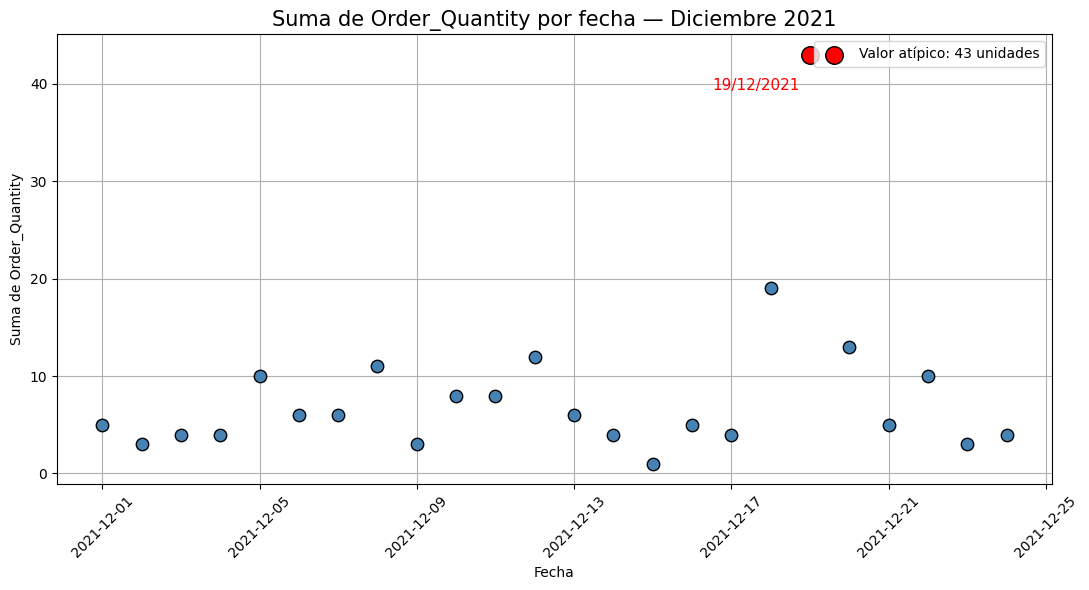

In [12]:
plt.figure(figsize=(11, 6))
plt.scatter(tabla_dinamica['Date'], tabla_dinamica['Sum_of_Order_Quantity'],
            color='steelblue', s=80, edgecolor='black', zorder=3)

# Resaltar el valor atípico
plt.scatter(fecha_max, cantidad_max, color='red', s=160, edgecolor='black',
            zorder=4, label=f'Valor atípico: {cantidad_max} unidades')
plt.annotate(f'{fecha_max.strftime("%d/%m/%Y")}',
             xy=(fecha_max, cantidad_max), xytext=(-70, -25),
             textcoords='offset points', fontsize=11, color='red')

plt.title('Suma de Order_Quantity por fecha — Diciembre 2021', fontsize=15)
plt.xlabel('Fecha')
plt.ylabel('Suma de Order_Quantity')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación:** el punto del 19 de diciembre se separa notoriamente del resto de la nube de puntos. Mientras los demás días se mueven entre 1 y 19 unidades, ese día alcanza 43, lo que lo convierte en un candidato claro a valor atípico.

## Paso 5 — Funciones GRANDE y PEQUEÑO (LARGE / SMALL)

| Excel | Python equivalente |
|---|---|
| `=GRANDE($E$4:$E$27; 1)` | `.nlargest(1)` |
| `=GRANDE($E$4:$E$27; FILA($1:5))` | `.nlargest(5)` |
| `=PEQUEÑO($E$4:$E$27; FILA($1:6))` | `.nsmallest(6)` |

In [13]:
serie = tabla_dinamica['Sum_of_Order_Quantity']

print('a) =GRANDE(rango, 1)  -> valor más alto:')
print(f'   {serie.nlargest(1).values[0]}\n')

print('b) =GRANDE(rango, FILA($1:5))  -> 5 valores más altos:')
print(f'   {serie.nlargest(5).values.tolist()}\n')

print('   ¿Qué función devolvería los 6 valores más bajos?')
print('   -> =PEQUEÑO($E$4:$E$27; FILA($1:6))   [SMALL en inglés]')
print(f'   {serie.nsmallest(6).values.tolist()}')

a) =GRANDE(rango, 1)  -> valor más alto:
   43

b) =GRANDE(rango, FILA($1:5))  -> 5 valores más altos:
   [43, 19, 13, 12, 11]

   ¿Qué función devolvería los 6 valores más bajos?
   -> =PEQUEÑO($E$4:$E$27; FILA($1:6))   [SMALL en inglés]
   [1, 3, 3, 3, 4, 4]


## Tratamiento de los valores atípicos



In [14]:
# OPCIÓN 1: eliminar el registro atípico
data_sin_outlier = data.drop(index=detalle_19dic.index[0]).copy()
print(f'Filas originales: {len(data)}  ->  Filas sin el outlier: {len(data_sin_outlier)}')

# OPCIÓN 2: normalizar el valor
tabla_normalizada = tabla_dinamica.copy()
segundo_max = tabla_dinamica['Sum_of_Order_Quantity'].nlargest(2).values[1]
tabla_normalizada.loc[tabla_normalizada['Date'] == fecha_max, 'Sum_of_Order_Quantity'] = segundo_max + 1

print(f'\nValor original del 19/12: {cantidad_max}')
print(f'Valor normalizado:        {segundo_max + 1}  (justo por encima del máximo de {segundo_max})')

Filas originales: 88  ->  Filas sin el outlier: 87

Valor original del 19/12: 43
Valor normalizado:        20  (justo por encima del máximo de 19)


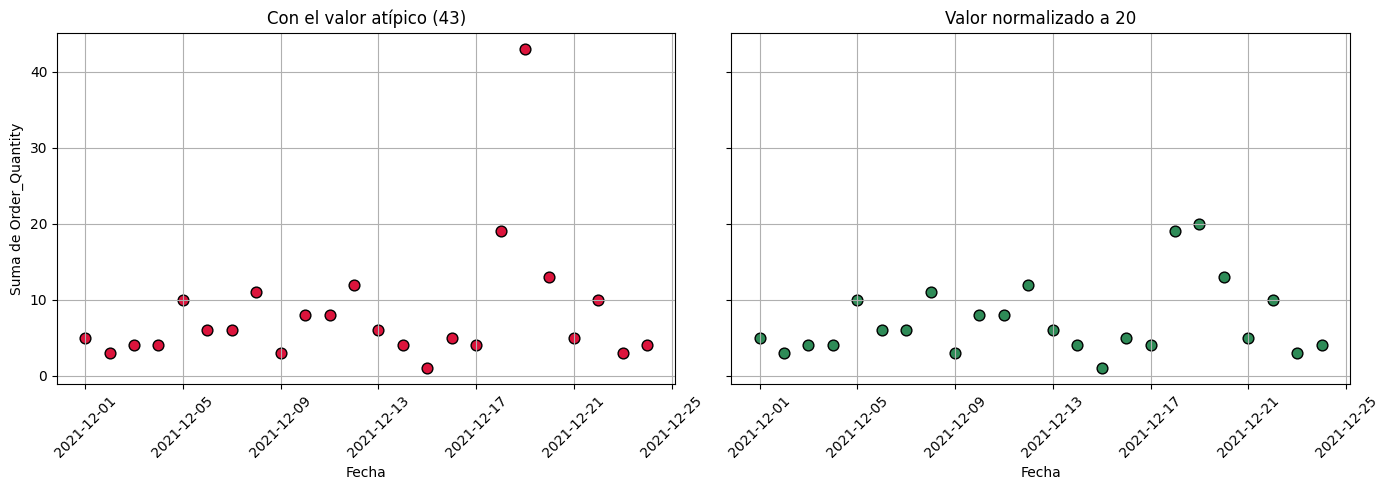

In [15]:
# Comparación visual: antes y después de normalizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(tabla_dinamica['Date'], tabla_dinamica['Sum_of_Order_Quantity'],
                color='crimson', s=60, edgecolor='black')
axes[0].set_title('Con el valor atípico (43)')
axes[0].set_ylabel('Suma de Order_Quantity')

axes[1].scatter(tabla_normalizada['Date'], tabla_normalizada['Sum_of_Order_Quantity'],
                color='seagreen', s=60, edgecolor='black')
axes[1].set_title(f'Valor normalizado a {segundo_max + 1}')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('Fecha')

plt.tight_layout()
plt.show()

## Gráfico de dispersión: Cantidad de órdenes vs. Ingresos



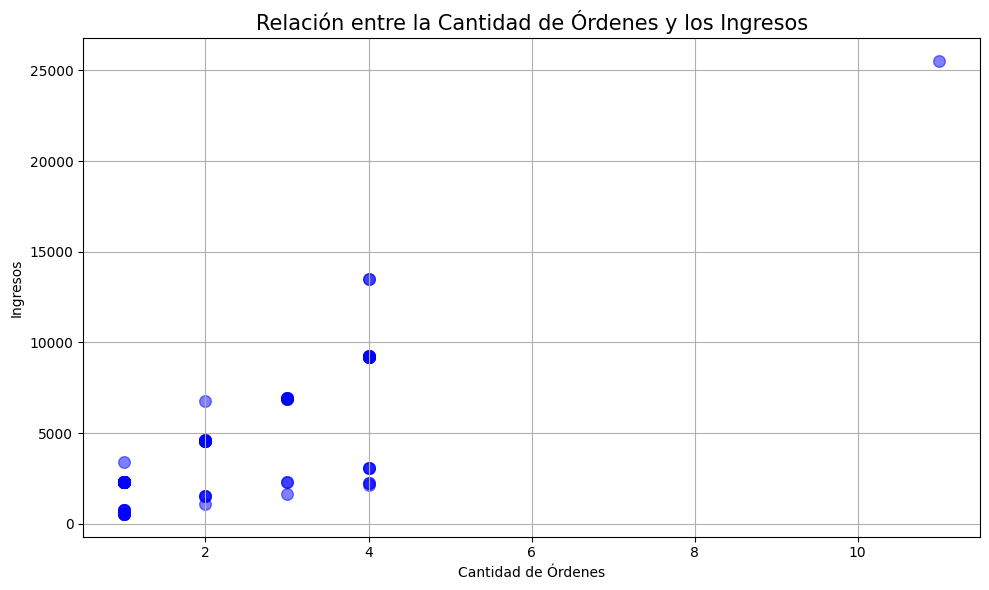

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(data['Order_Quantity'], data['Revenue'], color='b', alpha=0.5, s=70)

plt.title('Relación entre la Cantidad de Órdenes y los Ingresos', fontsize=15)
plt.xlabel('Cantidad de Órdenes')
plt.ylabel('Ingresos')
plt.tight_layout()
plt.show()

### Interpretación

1. **Relación entre cantidad de órdenes e ingresos:** en general, a mayor cantidad de órdenes los ingresos tienden a subir. Sin embargo, el crecimiento no es proporcional: hay pedidos pequeños que generan ingresos muy altos.

2. **Variabilidad:** para cantidades pequeñas (1 a 4 unidades) los ingresos se dispersan bastante. Esto se explica por la diferencia de precio entre productos — vender una bicicleta de alta gama no equivale a vender varios accesorios.

3. **Valores atípicos:** el punto de la esquina superior derecha combina una cantidad de órdenes muy alta con un ingreso excepcional. Corresponde al pedido del 19 de diciembre y distorsiona la escala del gráfico.

4. **Análisis adicional:** cruzar estos datos con `Customer_Age`, `Country` o `Product_Category` ayudaría a entender por qué algunas órdenes generan tanto más ingreso que otras.

## Preguntas de reflexión

**¿Qué factores determinan si un valor atípico debe o no considerarse en el análisis final?**

- **Origen del dato:** si proviene de un error de digitación o de medición, debe corregirse o eliminarse. Si corresponde a una transacción real y verificable, debe conservarse.
- **Tamaño del conjunto de datos:** en un dataset grande, quitar un par de atípicos casi no afecta el resultado; en uno pequeño como este (24 días) sí puede cambiar las conclusiones.
- **Objetivo del análisis:** si se busca el comportamiento típico del negocio, el atípico estorba. Si se busca detectar ventas excepcionales o fraude, el atípico *es* la información relevante.
- **Impacto sobre los estadísticos:** la media y la desviación estándar se ven muy afectadas por los atípicos; la mediana no. Conviene revisar ambos.
- **Trazabilidad:** siempre se debe trabajar sobre una copia y documentar qué se eliminó o ajustó, para poder investigar después la causa del valor atípico.

---
# EJERCICIO DE PRÁCTICA 2 — Escenarios de visualización

## 1. Comparación de calificaciones de estudiantes en diferentes asignaturas

Se quiere comparar las calificaciones promedio de los estudiantes en distintas materias para detectar diferencias de rendimiento.

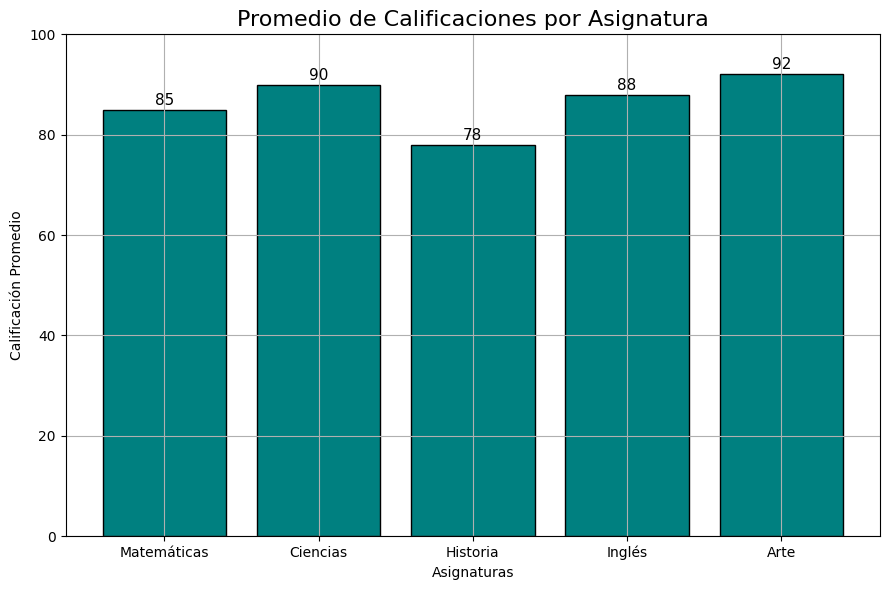

In [17]:
asignaturas = ['Matemáticas', 'Ciencias', 'Historia', 'Inglés', 'Arte']
calificaciones = [85, 90, 78, 88, 92]

plt.figure(figsize=(9, 6))
barras = plt.bar(asignaturas, calificaciones, color='teal', edgecolor='black')

# Etiqueta con el valor sobre cada barra
for barra, valor in zip(barras, calificaciones):
    plt.text(barra.get_x() + barra.get_width()/2, valor + 1, str(valor),
             ha='center', fontsize=11)

plt.title('Promedio de Calificaciones por Asignatura', fontsize=16)
plt.xlabel('Asignaturas')
plt.ylabel('Calificación Promedio')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Interpretación:** el gráfico de barras permite comparar el rendimiento promedio en cada materia. Arte (92) y Ciencias (90) presentan los mejores resultados, mientras que Historia (78) queda claramente por debajo del resto. La diferencia entre la materia más alta y la más baja es de 14 puntos, lo que sugiere revisar la metodología o la carga de contenido en Historia.

## 2. Comparación del tiempo de carga de diferentes páginas web

Se quiere visualizar el tiempo promedio de carga de diferentes sitios web para identificar cuál es más rápido o lento.

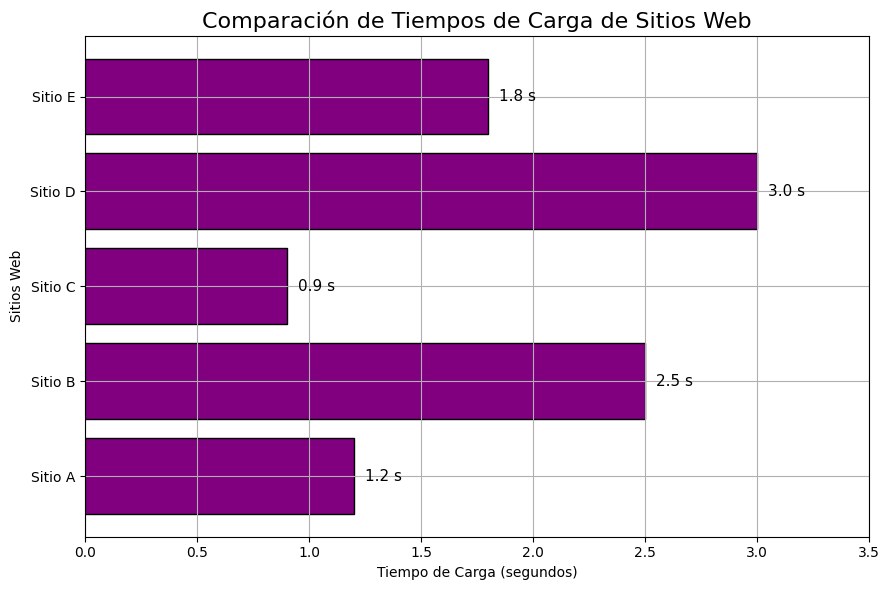

In [18]:
sitios = ['Sitio A', 'Sitio B', 'Sitio C', 'Sitio D', 'Sitio E']
tiempos = [1.2, 2.5, 0.9, 3.0, 1.8]

plt.figure(figsize=(9, 6))
barras = plt.barh(sitios, tiempos, color='purple', edgecolor='black')

for barra, valor in zip(barras, tiempos):
    plt.text(valor + 0.05, barra.get_y() + barra.get_height()/2,
             f'{valor} s', va='center', fontsize=11)

plt.title('Comparación de Tiempos de Carga de Sitios Web', fontsize=16)
plt.xlabel('Tiempo de Carga (segundos)')
plt.ylabel('Sitios Web')
plt.xlim(0, 3.5)
plt.tight_layout()
plt.show()

**Interpretación:** el gráfico de barras horizontales facilita comparar etiquetas de texto largas. El Sitio C es el más rápido con 0.9 segundos, mientras que el Sitio D es el más lento con 3.0 segundos — más de tres veces la demora del Sitio C. Considerando que se recomienda un tiempo de carga por debajo de 2 segundos, los sitios B y D requieren optimización.

## 3. Relación entre horas de estudio y rendimiento académico

Se quiere ver si existe una correlación entre las horas de estudio y el rendimiento en los exámenes.

Coeficiente de correlación de Pearson: 0.9863


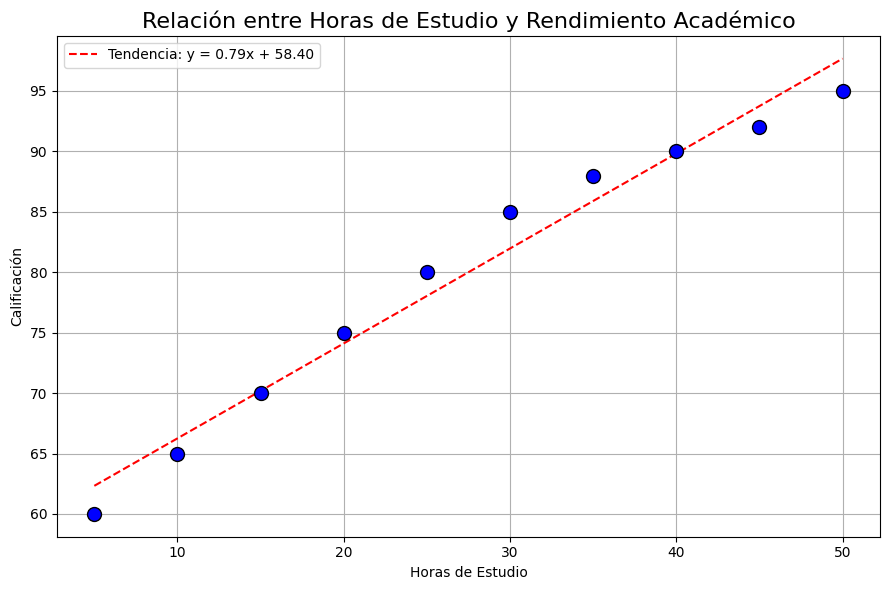

In [19]:
horas_estudio = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
calificaciones_ex = [60, 65, 70, 75, 80, 85, 88, 90, 92, 95]

plt.figure(figsize=(9, 6))
plt.scatter(horas_estudio, calificaciones_ex, color='blue', s=100, edgecolor='black', zorder=3)

# Línea de tendencia
coef = np.polyfit(horas_estudio, calificaciones_ex, 1)
plt.plot(horas_estudio, np.poly1d(coef)(horas_estudio), 'r--',
         label=f'Tendencia: y = {coef[0]:.2f}x + {coef[1]:.2f}')

correlacion = np.corrcoef(horas_estudio, calificaciones_ex)[0, 1]
print(f'Coeficiente de correlación de Pearson: {correlacion:.4f}')

plt.title('Relación entre Horas de Estudio y Rendimiento Académico', fontsize=16)
plt.xlabel('Horas de Estudio')
plt.ylabel('Calificación')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación:** el gráfico de dispersión muestra una correlación positiva muy fuerte (r ≈ 0.99) entre las horas de estudio y las calificaciones. Sin embargo, la relación no es perfectamente lineal: entre 5 y 30 horas cada bloque de estudio suma 5 puntos, mientras que a partir de las 30 horas la ganancia se reduce a 2 o 3 puntos. Esto refleja un rendimiento decreciente estudiar más siempre ayuda, pero cada hora adicional aporta menos que la anterior.

## 4. Distribución de salarios en tres departamentos distintos

Se quiere visualizar la variabilidad y la mediana de los salarios en cada departamento.

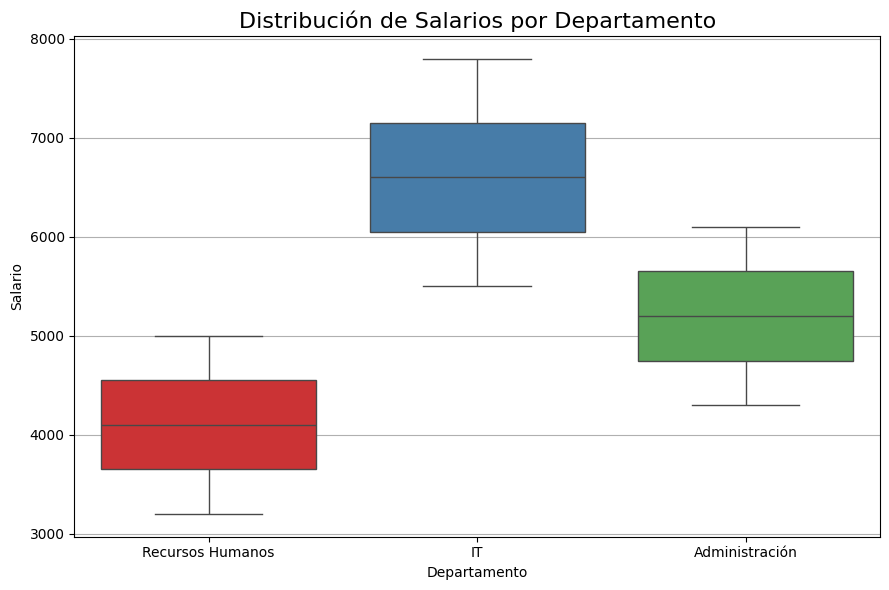

,min,25%,50%,75%,max
Departamento,,,,,
Administración,4300.0,4750.0,5200.0,5650.0,6100.0
IT,5500.0,6050.0,6600.0,7150.0,7800.0
Recursos Humanos,3200.0,3650.0,4100.0,4550.0,5000.0


In [20]:
datos_salarios = {
    'Departamento': ['Recursos Humanos']*10 + ['IT']*10 + ['Administración']*10,
    'Salario': [3200, 3400, 3600, 3800, 4000, 4200, 4400, 4600, 4800, 5000,
                5500, 5700, 6000, 6200, 6500, 6700, 7000, 7200, 7500, 7800,
                4300, 4500, 4700, 4900, 5100, 5300, 5500, 5700, 5900, 6100]
}

df_salarios = pd.DataFrame(datos_salarios)

plt.figure(figsize=(9, 6))
sns.boxplot(x='Departamento', y='Salario', data=df_salarios,
            hue='Departamento', palette='Set1', legend=False)

plt.title('Distribución de Salarios por Departamento', fontsize=16)
plt.xlabel('Departamento')
plt.ylabel('Salario')
plt.tight_layout()
plt.show()

# Estadísticos descriptivos que respaldan la interpretación
df_salarios.groupby('Departamento')['Salario'].describe()[['min', '25%', '50%', '75%', 'max']]

**Interpretación:** el diagrama de cajas resume la distribución salarial de los tres departamentos. IT concentra la mediana más alta (6600) y también el rango más amplio, lo que indica mayor dispersión entre los salarios de entrada y los senior. Recursos Humanos tiene la mediana más baja (4100) y Administración se ubica en un punto intermedio (5200) con la distribución más compacta. Ningún departamento presenta valores atípicos: no aparecen puntos fuera de los bigotes.

>

---
## Conclusiones del laboratorio

- Los valores atípicos pueden detectarse por varios caminos: ordenando los datos, con un gráfico de dispersión, o con funciones como GRANDE/PEQUEÑO (`nlargest`/`nsmallest` en pandas). La visualización suele ser el método más rápido para conjuntos grandes.
- En el dataset de ventas de bicicletas, el 19 de diciembre de 2021 destaca con 43 unidades frente a un máximo de 19 en los demás días.
- Cada tipo de gráfico responde a una pregunta distinta: barras para comparar categorías, barras horizontales cuando las etiquetas son largas, dispersión para relaciones entre dos variables numéricas y cajas para distribuciones y detección de atípicos.
- Antes de eliminar un valor atípico hay que investigar su origen: puede ser un error o puede ser el dato más valioso del conjunto.